# Metropolitan Restaurant Market Analysis

**Executive Summary**
This report presents an exploratory data analysis (EDA) of local metropolitan restaurants. The objective is to identify key market trends, specifically focusing on rating distributions, pricing strategies across different cuisines, and high-performance establishments delivering strategic menu items (e.g., Chocolate Cake).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization aesthetics
sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')


## 1. Data Acquisition and Generation

For the purpose of this analysis, a dataset is generated representing a localized cross-section of the restaurant industry. The dataset captures essential business metrics, including pricing, customer sentiment (ratings), review volume, and signature offerings.


In [2]:
# Set random seed for reproducibility
np.random.seed(42)

restaurants = [
    "The Rustic Spoon", "Ocean Breeze Diner", "Urban Spice", "Green Leaf Cafe", 
    "Steak & Stone", "Noodle Haven", "Taco Fiesta", "Bistro 49", 
    "Golden Dragon", "Luigi's Trattoria", "Spice Route", "Burger Joint",
    "Sushi Sensation", "Pancake House", "The Chocolate Factory", "Wrap City",
    "Mediterranean Delight", "BBQ Pit", "Vegan Vibes", "Seafood Cove"
]

cuisines = [
    "American", "Seafood", "Indian", "Healthy", 
    "Steakhouse", "Asian", "Mexican", "French", 
    "Chinese", "Italian", "Indian", "American", 
    "Japanese", "American", "Dessert", "Fast Food", 
    "Mediterranean", "BBQ", "Vegan", "Seafood"
]

signature_items = [
    "Truffle Fries", "Grilled Salmon", "Chicken Tikka Masala", "Quinoa Bowl",
    "Ribeye Steak", "Pad Thai", "Al Pastor Tacos", "Coq au Vin",
    "Peking Duck", "Margherita Pizza", "Biryani", "Classic Cheeseburger",
    "Spicy Tuna Roll", "Blueberry Pancakes", "Artisan Truffles", "Chicken Wrap",
    "Falafel Platter", "Smoked Brisket", "Beyond Burger", "Lobster Roll"
]

# Strategic assignment of 'Chocolate Cake' for targeted segment analysis
target_item = "Chocolate Cake"
for idx in [3, 7, 11, 14, 19]:
    signature_items[idx] = target_item

data = {
    "Restaurant_ID": range(101, 121),
    "Restaurant_Name": restaurants,
    "Cuisine_Type": cuisines,
    "Average_Price_USD": np.random.uniform(15, 95, 20).round(2),
    "Rating": np.random.uniform(3.2, 5.0, 20).round(1),
    "Total_Reviews": np.random.randint(100, 2500, 20),
    "Signature_Item": signature_items
}

df = pd.DataFrame(data)

# Introduce controlled missingness to simulate real-world data anomalies
df.loc[2, 'Rating'] = np.nan
df.loc[8, 'Average_Price_USD'] = np.nan
df.loc[15, 'Total_Reviews'] = np.nan

df.head()


,Restaurant_ID,Restaurant_Name,Cuisine_Type,Average_Price_USD,Rating,Total_Reviews,Signature_Item
0,101,The Rustic Spoon,American,44.96,4.3,1578.0,Truffle Fries
1,102,Ocean Breeze Diner,Seafood,91.06,3.5,875.0,Grilled Salmon
2,103,Urban Spice,Indian,73.56,NaN,134.0,Chicken Tikka Masala
3,104,Green Leaf Cafe,Healthy,62.89,3.9,2353.0,Chocolate Cake
4,105,Steak & Stone,Steakhouse,27.48,4.0,2055.0,Ribeye Steak


## 2. Data Cleaning and Preprocessing

Robust analytics require consistent and complete datasets. Here, we identify missing values and apply appropriate imputation techniques. Ratings and reviews utilize median imputation to resist outliers, while pricing utilizes mean imputation to preserve expected revenue characteristics.


In [3]:
# Assess data completeness
missing_report = df.isnull().sum()
print("Initial Missing Data Profile:\n", missing_report[missing_report > 0], "\n")

# Impute missing values
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
df['Average_Price_USD'] = df['Average_Price_USD'].fillna(df['Average_Price_USD'].mean())
df['Total_Reviews'] = df['Total_Reviews'].fillna(df['Total_Reviews'].median())

# Verify integrity
print("Post-Imputation Missing Values:\n", df.isnull().sum().sum())


Initial Missing Data Profile:
 Average_Price_USD    1
Rating               1
Total_Reviews        1
dtype: int64 

Post-Imputation Missing Values:
 0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Establishing Market Leaders

Identifying the highest-rated establishments provides benchmarks for competitive analysis and excellence in customer satisfaction.


In [4]:
market_leaders = df.nlargest(5, 'Rating')
market_leaders[['Restaurant_Name', 'Cuisine_Type', 'Rating', 'Total_Reviews']]


,Restaurant_Name,Cuisine_Type,Rating,Total_Reviews
13,Pancake House,American,4.9,2081.0
14,The Chocolate Factory,Dessert,4.9,1095.0
15,Wrap City,Fast Food,4.7,1121.0
5,Noodle Haven,Asian,4.6,1685.0
18,Vegan Vibes,Vegan,4.4,1375.0


### 3.2 Targeted Segment Analysis: High-End Chocolate Cake Providers

Isolating establishments that serve the target signature item ('Chocolate Cake') while maintaining premium customer satisfaction (Rating >= 4.0). This outlines strategic locations for dessert-focused partnerships.


In [5]:
chocolate_cake_segment = df[(df['Signature_Item'] == "Chocolate Cake") & (df['Rating'] >= 4.0)]
chocolate_cake_segment.sort_values(by='Rating', ascending=False)[['Restaurant_Name', 'Cuisine_Type', 'Rating', 'Signature_Item']]


,Restaurant_Name,Cuisine_Type,Rating,Signature_Item
14,The Chocolate Factory,Dessert,4.9,Chocolate Cake
7,Bistro 49,French,4.1,Chocolate Cake
19,Seafood Cove,Seafood,4.0,Chocolate Cake


## 4. Market Visualizations

Visual analyses to uncover underlying distributions, categorical biases, and multivariate relationships within the dining landscape.


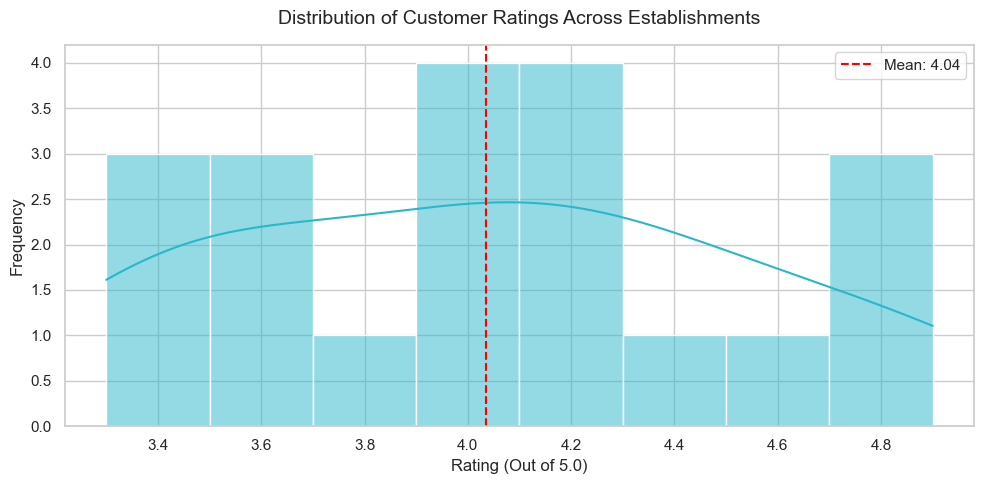

In [6]:
# 1. Distribution of Consumer Ratings
plt.figure(figsize=(10, 5))
sns.histplot(df['Rating'], bins=8, kde=True, color='#2ab7ca')
plt.title('Distribution of Customer Ratings Across Establishments', fontsize=14, pad=15)
plt.xlabel('Rating (Out of 5.0)')
plt.ylabel('Frequency')
plt.axvline(df['Rating'].mean(), color='red', linestyle='--', label=f"Mean: {df['Rating'].mean():.2f}")
plt.legend()
plt.tight_layout()
plt.show()


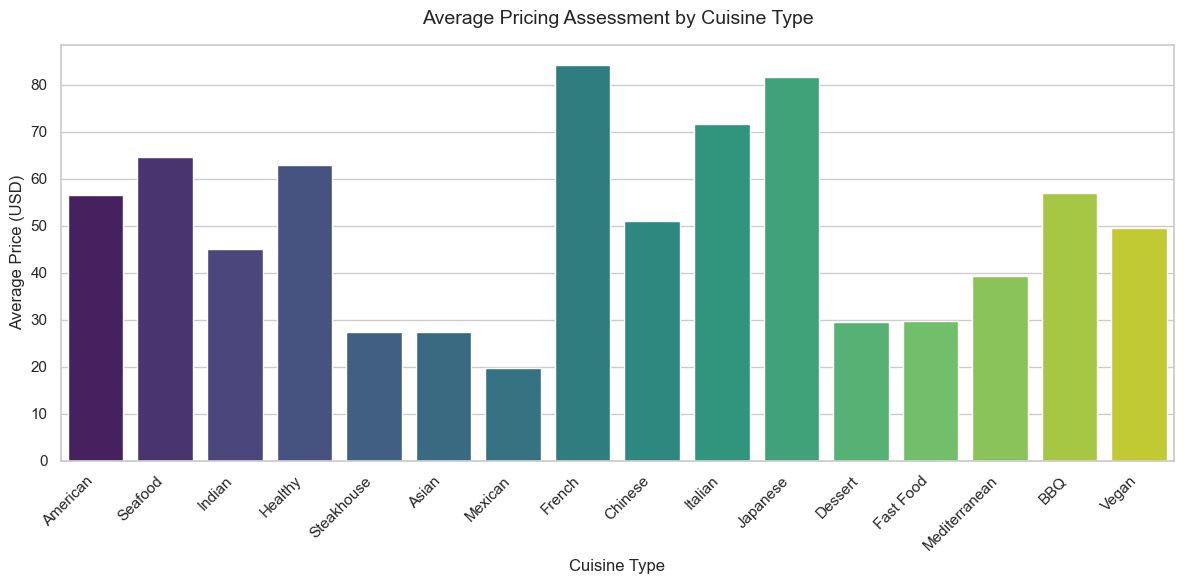

In [7]:
# 2. Pricing Power by Cuisine Category
plt.figure(figsize=(12, 6))
sns.barplot(x='Cuisine_Type', y='Average_Price_USD', data=df, errorbar=None, palette='viridis', hue='Cuisine_Type', legend=False)
plt.title('Average Pricing Assessment by Cuisine Type', fontsize=14, pad=15)
plt.xlabel('Cuisine Type')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


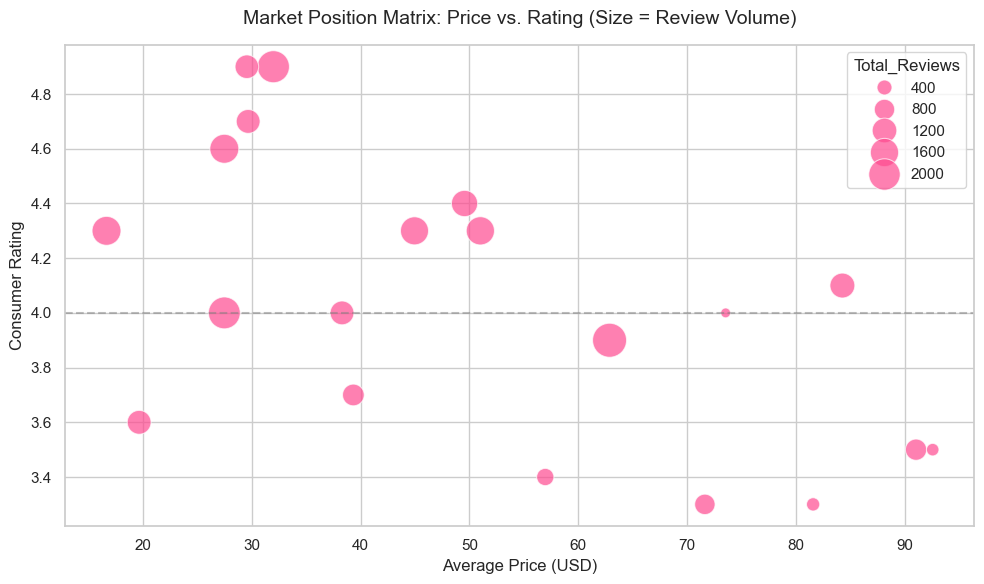

In [8]:
# 3. Multivariate Analysis: Price vs. Rating Volatility
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Average_Price_USD', 
    y='Rating', 
    size='Total_Reviews', 
    sizes=(50, 600), 
    data=df, 
    alpha=0.7, 
    color='#fe4a90'
)
plt.title('Market Position Matrix: Price vs. Rating (Size = Review Volume)', fontsize=14, pad=15)
plt.xlabel('Average Price (USD)')
plt.ylabel('Consumer Rating')
plt.axhline(4.0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Conclusion**
The analysis highlights the competitive pricing power of certain cuisine types and segments out premium providers for key items. The data foundation now supports further predictive modeling for market entry strategies.
